# NBA — Modèles ML (v2 avec features avancées)

XGBoost + NN Classique + QNN Hybride v2.

**Nouveautés v2 :**
- Features rolling avancées : Net Rating, Offensive/Defensive Rating, eFG%, Rebond, PIE
- Ces features sont bien plus corrélées avec home_win (~0.29 vs ~0.15 avant)

**Cibles :**
- `home_win` → probabilité P(victoire domicile)
- `point_diff` → différentiel de points

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    mean_absolute_error, mean_squared_error
)
from xgboost import XGBClassifier, XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print('Imports OK')

Imports OK


In [ ]:
X_train_xgb = pd.read_csv('../../data/nba/nba_X_train_xgb.csv')
X_val_xgb   = pd.read_csv('../../data/nba/nba_X_val_xgb.csv')
X_train_qnn = pd.read_csv('../../data/nba/nba_X_train_qnn.csv').values
X_val_qnn   = pd.read_csv('../../data/nba/nba_X_val_qnn.csv').values

y_train      = pd.read_csv('../../data/nba/nba_y_train.csv').values.ravel()
y_val        = pd.read_csv('../../data/nba/nba_y_val.csv').values.ravel()
y_train_diff = pd.read_csv('../../data/nba/nba_y_train_diff.csv').values.ravel()
y_val_diff   = pd.read_csv('../../data/nba/nba_y_val_diff.csv').values.ravel()

with open('../../data/nba/nba_features_qnn.pkl', 'rb') as f:
    features_qnn = pickle.load(f)
with open('../../data/nba/nba_features_xgb.pkl', 'rb') as f:
    features_xgb = pickle.load(f)

print(f'X_train_xgb : {X_train_xgb.shape}')
print(f'X_train_qnn : {X_train_qnn.shape}')
print(f'Baseline    : {y_val.mean():.1%}')
print(f'\nFeatures XGBoost ({len(features_xgb)}) : {features_xgb}')
print(f'\nFeatures QNN ({len(features_qnn)}) : {features_qnn}')

results = {}

X_train_xgb : (2532, 19)
X_train_qnn : (2532, 16)
Baseline    : 54.6%

Features XGBoost (19) : ['is_playoffs', 'diff_roll_estimatedNetRating_10', 'diff_roll_estimatedOffensiveRating_10', 'diff_roll_estimatedDefensiveRating_10', 'diff_roll_effectiveFieldGoalPercentage_10', 'diff_roll_defensiveReboundPercentage_10', 'home_roll_estimatedNetRating_10', 'away_roll_estimatedNetRating_10', 'home_roll_pts_for_10', 'away_roll_pts_for_10', 'home_roll_pts_against_10', 'away_roll_pts_against_10', 'scoring_momentum', 'home_rest_days', 'away_rest_days', 'home_is_b2b', 'away_is_b2b', 'rest_diff', 'b2b_advantage']

Features QNN (16) : ['is_playoffs', 'diff_roll_estimatedNetRating_10', 'diff_roll_estimatedOffensiveRating_10', 'diff_roll_estimatedDefensiveRating_10', 'diff_roll_effectiveFieldGoalPercentage_10', 'diff_roll_defensiveReboundPercentage_10', 'home_roll_estimatedNetRating_10', 'away_roll_estimatedNetRating_10', 'home_roll_pts_for_10', 'away_roll_pts_for_10', 'home_roll_pts_against_10', 'away_

In [3]:
def evaluate(name, y_true, y_pred_proba):
    y_pred  = (y_pred_proba >= 0.5).astype(int)
    acc     = accuracy_score(y_true, y_pred)
    auc     = roc_auc_score(y_true, y_pred_proba)
    ll      = log_loss(y_true, y_pred_proba)
    results[name] = {'accuracy': acc, 'auc': auc, 'log_loss': ll}
    print(f'\n=== {name} ===')
    print(f'  Accuracy : {acc:.1%}')
    print(f'  AUC-ROC  : {auc:.3f}')
    print(f'  Log Loss : {ll:.4f}')
    print(f'  Baseline : {y_true.mean():.1%}')
    return y_pred_proba

## 1. XGBoost

In [4]:
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='logloss', early_stopping_rounds=20, verbosity=0
)
xgb_clf.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
xgb_proba = xgb_clf.predict_proba(X_val_xgb)[:, 1]
evaluate('XGBoost', y_val, xgb_proba)


=== XGBoost ===
  Accuracy : 62.7%
  AUC-ROC  : 0.668
  Log Loss : 0.6467
  Baseline : 54.6%


array([0.7389229 , 0.6431493 , 0.72213775, ..., 0.75346994, 0.5586783 ,
       0.6267734 ], shape=(1309,), dtype=float32)

In [5]:
xgb_reg = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0)
xgb_reg.fit(X_train_xgb, y_train_diff)
xgb_diff_pred = xgb_reg.predict(X_val_xgb)
mae  = mean_absolute_error(y_val_diff, xgb_diff_pred)
rmse = np.sqrt(mean_squared_error(y_val_diff, xgb_diff_pred))
print(f'\n=== XGBoost Régression ===')
print(f'  MAE  : {mae:.2f} points')
print(f'  RMSE : {rmse:.2f} points')


=== XGBoost Régression ===
  MAE  : 12.06 points
  RMSE : 15.34 points


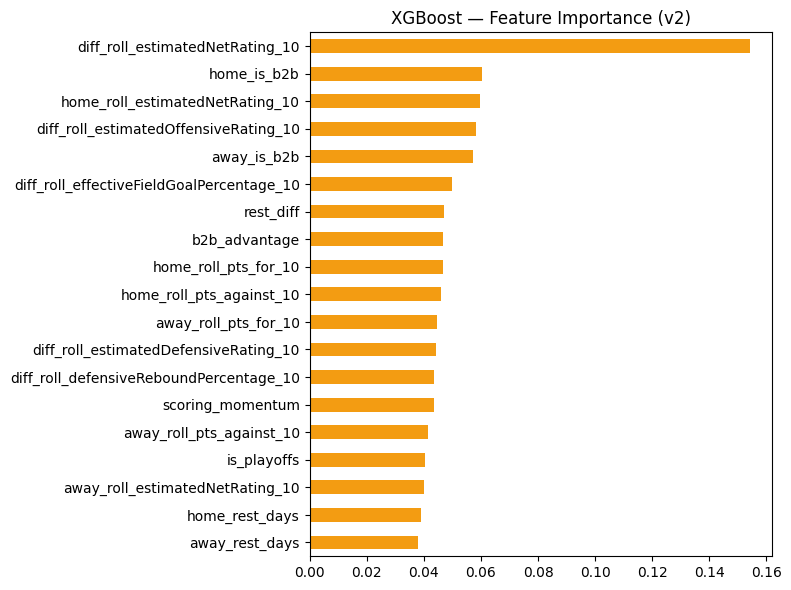

diff_roll_estimatedNetRating_10              0.154222
home_is_b2b                                  0.060318
home_roll_estimatedNetRating_10              0.059527
diff_roll_estimatedOffensiveRating_10        0.058124
away_is_b2b                                  0.057267
diff_roll_effectiveFieldGoalPercentage_10    0.049864
rest_diff                                    0.046871
b2b_advantage                                0.046801
home_roll_pts_for_10                         0.046615
home_roll_pts_against_10                     0.045908
away_roll_pts_for_10                         0.044455
diff_roll_estimatedDefensiveRating_10        0.044127
diff_roll_defensiveReboundPercentage_10      0.043637
scoring_momentum                             0.043414
away_roll_pts_against_10                     0.041379
is_playoffs                                  0.040337
away_roll_estimatedNetRating_10              0.040116
home_rest_days                               0.038944
away_rest_days              

In [6]:
fi = pd.Series(xgb_clf.feature_importances_, index=X_train_xgb.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
fi.plot(kind='barh', color='#f39c12')
plt.title('XGBoost — Feature Importance (v2)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('data/nba_xgb_importance_v2.png', dpi=100, bbox_inches='tight')
plt.show()
print(fi.to_string())

In [ ]:
with open('../../models/nba/nba_xgb_clf.pkl', 'wb') as f:
    pickle.dump(xgb_clf, f)
with open('../../models/nba/nba_xgb_reg.pkl', 'wb') as f:
    pickle.dump(xgb_reg, f)
print('XGBoost sauvegardé')

XGBoost sauvegardé


## 2. Réseau de neurones classique

In [ ]:
X_tr = torch.tensor(X_train_qnn, dtype=torch.float32)
y_tr = torch.tensor(y_train,     dtype=torch.float32)
X_v  = torch.tensor(X_val_qnn,   dtype=torch.float32)
y_v  = torch.tensor(y_val,       dtype=torch.float32)

train_ds = TensorDataset(X_tr, y_tr)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

class ClassicNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

nn_model  = ClassicNN(X_train_qnn.shape[1])
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    nn_model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(nn_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    nn_model.eval()
    with torch.no_grad():
        val_loss = criterion(nn_model(X_v), y_v).item()
    train_losses.append(epoch_loss / len(train_dl))
    val_losses.append(val_loss)
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} — train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}')

nn_model.eval()
with torch.no_grad():
    nn_proba = nn_model(X_v).numpy()
evaluate('NN Classique', y_val, nn_proba)
torch.save(nn_model.state_dict(), '../../models/nba/nba_nn_classic_v2.pt')
print('NN classique sauvegardé')

Epoch  20 — train: 0.6425  val: 0.6347
Epoch  40 — train: 0.6355  val: 0.6375
Epoch  60 — train: 0.6325  val: 0.6400
Epoch  80 — train: 0.6294  val: 0.6427
Epoch 100 — train: 0.6212  val: 0.6440

=== NN Classique ===
  Accuracy : 62.7%
  AUC-ROC  : 0.673
  Log Loss : 0.6440
  Baseline : 54.6%
NN classique sauvegardé


## 3. QNN Hybride v2 (Dense + Circuit Quantique)

In [9]:
import pennylane as qml

N_QUBITS = 8
N_LAYERS = 3

X_train_8 = X_train_qnn[:, :8]
X_val_8   = X_val_qnn[:, :8]

print(f'Features QNN (8 premières) :')
for f in features_qnn[:8]:
    print(f'  {f}')

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def quantum_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(N_QUBITS), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

class HybridQNNv2(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.classical = nn.Sequential(nn.Linear(n_qubits, n_qubits), nn.Tanh())
        self.weights = nn.Parameter(
            torch.tensor(np.random.uniform(0, np.pi, (n_layers, n_qubits)), dtype=torch.float32)
        )
        self.scaling = nn.Parameter(torch.ones(1))
        self.bias    = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        x_prep = self.classical(x) * np.pi
        out = torch.stack([
            quantum_circuit(x_prep[i], self.weights)
            for i in range(x.shape[0])
        ]).float()
        return torch.sigmoid(self.scaling * out + self.bias)

qnn_model = HybridQNNv2(N_QUBITS, N_LAYERS)
print(f'\nQNN : {N_QUBITS} qubits, {N_LAYERS} layers')
print(f'Paramètres : {sum(p.numel() for p in qnn_model.parameters())}')

Features QNN (8 premières) :
  is_playoffs
  diff_roll_estimatedNetRating_10
  diff_roll_estimatedOffensiveRating_10
  diff_roll_estimatedDefensiveRating_10
  diff_roll_effectiveFieldGoalPercentage_10
  diff_roll_defensiveReboundPercentage_10
  home_roll_estimatedNetRating_10
  away_roll_estimatedNetRating_10

QNN : 8 qubits, 3 layers
Paramètres : 98


In [ ]:
N_SAMPLE   = 2578
EPOCHS_QNN = 60
BATCH_SIZE = 128
LR_QNN     = 0.01

X_tr_q = torch.tensor(X_train_8[:N_SAMPLE], dtype=torch.float32)
y_tr_q = torch.tensor(y_train[:N_SAMPLE],   dtype=torch.float32)
X_v_q  = torch.tensor(X_val_8[:500],        dtype=torch.float32)
y_v_q  = torch.tensor(y_val[:500],          dtype=torch.float32)

train_ds_q = TensorDataset(X_tr_q, y_tr_q)
train_dl_q = DataLoader(train_ds_q, batch_size=BATCH_SIZE, shuffle=True)
optimizer_q = torch.optim.Adam(qnn_model.parameters(), lr=LR_QNN)
criterion_q = nn.BCELoss()

best_val_loss = float('inf')
patience, no_improve = 10, 0

print(f'HybridQNNv2 : {N_QUBITS} qubits, {N_SAMPLE} samples, patience={patience}')

for epoch in range(EPOCHS_QNN):
    qnn_model.train()
    epoch_loss = 0
    for xb, yb in train_dl_q:
        optimizer_q.zero_grad()
        loss = criterion_q(qnn_model(xb), yb)
        loss.backward()
        optimizer_q.step()
        epoch_loss += loss.item()

    qnn_model.eval()
    with torch.no_grad():
        val_loss = criterion_q(qnn_model(X_v_q), y_v_q).item()

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        torch.save(qnn_model.state_dict(), '../../models/nba/nba_qnn_v2_best.pt')
        no_improve = 0
    else:
        no_improve += 1

    print(f'Epoch {epoch+1:2d}/{EPOCHS_QNN} — '
          f'train: {epoch_loss/len(train_dl_q):.4f}  val: {val_loss:.4f}'
          + (' ← best' if is_best else f' (patience {no_improve}/{patience})'))

    if no_improve >= patience:
        print(f'\nEarly stopping à l\'epoch {epoch+1}')
        break

qnn_model.load_state_dict(torch.load('../../models/nba/nba_qnn_v2_best.pt'))
print(f'\nMeilleur modèle — val_loss: {best_val_loss:.4f}')

qnn_model.eval()
with torch.no_grad():
    qnn_proba = qnn_model(X_v_q).numpy()

evaluate('QNN Hybride v2', y_val[:500], qnn_proba)
torch.save(qnn_model.state_dict(), '../../models/nba/nba_qnn_v2_weights.pt')
print('QNN v2 sauvegardé')

HybridQNNv2 : 8 qubits, 2578 samples, patience=10


KeyboardInterrupt: 

## 4. Comparaison des 3 modèles

=== COMPARAISON FINALE (v2) ===
                accuracy     auc  log_loss
QNN Hybride v2    0.6320  0.6906    0.6274
NN Classique      0.6272  0.6732    0.6440
XGBoost           0.6272  0.6681    0.6467

Baseline : 54.6%


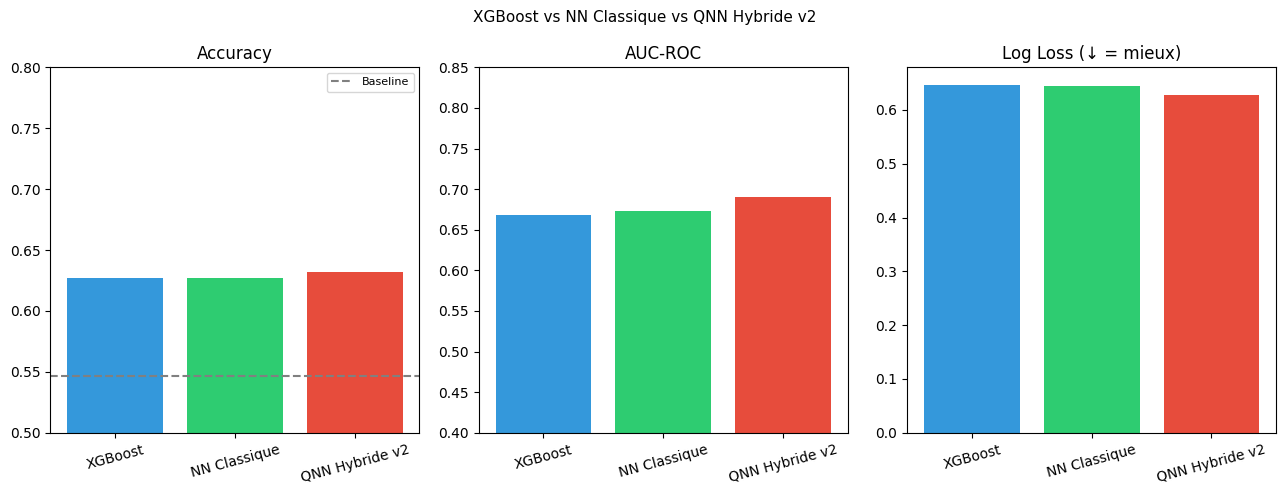

In [ ]:
df_results = pd.DataFrame(results).T.sort_values('auc', ascending=False)
print('=== COMPARAISON FINALE (v2) ===')
print(df_results.round(4).to_string())
print(f'\nBaseline : {y_val.mean():.1%}')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
models = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, title, ylim in zip(
    axes,
    ['accuracy', 'auc', 'log_loss'],
    ['Accuracy', 'AUC-ROC', 'Log Loss (↓ = mieux)'],
    [(0.5, 0.80), (0.4, 0.85), None]
):
    ax.bar(models, [results[m][metric] for m in models], color=colors)
    if metric == 'accuracy':
        ax.axhline(y_val.mean(), color='gray', linestyle='--', label='Baseline')
        ax.legend(fontsize=8)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('XGBoost vs NN Classique vs QNN Hybride v2', fontsize=11)
plt.tight_layout()
plt.savefig('../../visualisation/nba/nba_model_comparison_v2.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Fonction de prédiction

In [ ]:
TEAM_MAP = {
    'LAL': 'Lakers',    'GSW': 'Warriors',    'BOS': 'Celtics',
    'MIA': 'Heat',      'PHX': 'Suns',        'DEN': 'Nuggets',
    'MIL': 'Bucks',     'PHI': '76ers',       'NYK': 'Knicks',
    'DAL': 'Mavericks', 'MEM': 'Grizzlies',   'NOP': 'Pelicans',
    'SAC': 'Kings',     'MIN': 'Timberwolves','OKC': 'Thunder',
    'LAC': 'Clippers',  'POR': 'Blazers',     'UTA': 'Jazz',
    'CHI': 'Bulls',     'CLE': 'Cavaliers',   'DET': 'Pistons',
    'IND': 'Pacers',    'ATL': 'Hawks',       'CHA': 'Hornets',
    'ORL': 'Magic',     'WAS': 'Wizards',     'BKN': 'Nets',
    'TOR': 'Raptors',   'HOU': 'Rockets',     'SAS': 'Spurs',
}

def predict_game(home_team, away_team,
                 home_rest_days=2, away_rest_days=2,
                 home_is_b2b=0, away_is_b2b=0,
                 is_playoffs=0, model='xgboost'):
    """
    Prédit le résultat d'un match NBA.
    home_team / away_team : trigramme NBA ('LAL') ou nom partiel ('Lakers')
    model : 'xgboost' | 'nn' | 'qnn'
    """
    team_stats  = pd.read_csv('../../data/nba/nba_team_stats_current.csv')
    team_recent = pd.read_csv('../../data/nba/nba_team_stats_recent.csv')

    home_name = TEAM_MAP.get(home_team, home_team)
    away_name = TEAM_MAP.get(away_team, away_team)

    home = team_stats[team_stats['TEAM_NAME'].str.contains(home_name, case=False)]
    away = team_stats[team_stats['TEAM_NAME'].str.contains(away_name, case=False)]

    if home.empty or away.empty:
        print(f'Équipes : {sorted(team_stats["TEAM_NAME"].tolist())}')
        raise ValueError(f'Introuvable : {home_name} ou {away_name}')

    home = home.iloc[0]
    away = away.iloc[0]

    with open('../../data/nba/nba_features_xgb.pkl', 'rb') as f:
        feat_xgb = pickle.load(f)
    with open('../../data/nba/nba_features_qnn.pkl', 'rb') as f:
        feat_qnn = pickle.load(f)
    with open('../../scalers/nba/nba_scaler_xgb.pkl', 'rb') as f:
        scaler_xgb = pickle.load(f)
    with open('../../scalers/nba/nba_scaler_qnn.pkl', 'rb') as f:
        scaler_qnn = pickle.load(f)

    STAT_MAP = {
        'diff_roll_estimatedNetRating_10':           home.get('NET_RATING', 0)    - away.get('NET_RATING', 0),
        'diff_roll_estimatedOffensiveRating_10':     home.get('OFF_RATING', 110)  - away.get('OFF_RATING', 110),
        'diff_roll_estimatedDefensiveRating_10':     home.get('DEF_RATING', 110)  - away.get('DEF_RATING', 110),
        'diff_roll_effectiveFieldGoalPercentage_10': home.get('EFG_PCT', 0.5)     - away.get('EFG_PCT', 0.5),
        'diff_roll_defensiveReboundPercentage_10':   home.get('DREB_PCT', 0.75)   - away.get('DREB_PCT', 0.75),
        'diff_roll_PIE_10':                          home.get('PIE', 0.5)          - away.get('PIE', 0.5),
        'home_roll_estimatedNetRating_10':           home.get('NET_RATING', 0),
        'away_roll_estimatedNetRating_10':           away.get('NET_RATING', 0),
        'home_roll_pts_for_10':                      home.get('PTS', 110),
        'away_roll_pts_for_10':                      away.get('PTS', 110),
        'home_roll_pts_against_10':                  away.get('PTS', 110),
        'away_roll_pts_against_10':                  home.get('PTS', 110),
        'home_roll_pt_diff_10':                      home.get('PLUS_MINUS', 0),
        'away_roll_pt_diff_10':                      away.get('PLUS_MINUS', 0),
        'pt_diff_diff_10':                           home.get('PLUS_MINUS', 0)   - away.get('PLUS_MINUS', 0),
        'scoring_momentum':                          home.get('PTS', 110)         - away.get('PTS', 110),
        'defense_momentum':                          away.get('PTS', 110)         - home.get('PTS', 110),
        'home_rest_days':   home_rest_days,
        'away_rest_days':   away_rest_days,
        'home_is_b2b':      home_is_b2b,
        'away_is_b2b':      away_is_b2b,
        'rest_diff':        home_rest_days - away_rest_days,
        'b2b_advantage':    away_is_b2b - home_is_b2b,
        'is_playoffs':      is_playoffs,
    }

    if model == 'xgboost':
        x = np.array([STAT_MAP.get(f, 0) for f in feat_xgb]).reshape(1, -1)
        p_home = xgb_clf.predict_proba(scaler_xgb.transform(x))[0, 1]
    elif model == 'nn':
        x = np.array([STAT_MAP.get(f, 0) for f in feat_qnn]).reshape(1, -1)
        x_t = torch.tensor(np.clip(scaler_qnn.transform(x), -np.pi, np.pi), dtype=torch.float32)
        nn_model.eval()
        with torch.no_grad():
            p_home = nn_model(x_t).item()
    else:  # qnn
        x = np.array([STAT_MAP.get(f, 0) for f in feat_qnn]).reshape(1, -1)
        x_scaled = np.clip(scaler_qnn.transform(x), -np.pi, np.pi)[:, :8]
        x_t = torch.tensor(x_scaled, dtype=torch.float32)
        qnn_model.eval()
        with torch.no_grad():
            p_home = qnn_model(x_t).item()

    p_away = 1 - p_home
    winner = home_name if p_home > 0.5 else away_name
    conf   = max(p_home, p_away)

    print(f'\n🏀 {home_name} (dom.) vs {away_name} (ext.)')
    print(f'   P({home_name} gagne) = {p_home:.1%}')
    print(f'   P({away_name} gagne) = {p_away:.1%}')
    print(f'   → {winner} ({conf:.1%} de confiance) [{model}]')
    if home_is_b2b:
        print(f'   ⚠ {home_name} en back-to-back')
    if away_is_b2b:
        print(f'   ⚠ {away_name} en back-to-back')

    return {'home': home_name, 'away': away_name,
            'p_home': round(float(p_home), 3),
            'p_away': round(float(p_away), 3),
            'winner': winner, 'confidence': round(float(conf), 3), 'model': model}

predict_game('LAL', 'GSW', model='xgboost')


🏀 Lakers (dom.) vs Warriors (ext.)
   P(Lakers gagne) = 63.2%
   P(Warriors gagne) = 36.8%
   → Lakers (63.2% de confiance) [xgboost]


{'home': 'Lakers',
 'away': 'Warriors',
 'p_home': 0.632,
 'p_away': 0.368,
 'winner': 'Lakers',
 'confidence': 0.632,
 'model': 'xgboost'}

In [16]:
predict_game('BOS', 'MIA', model='nn')


🏀 Celtics (dom.) vs Heat (ext.)
   P(Celtics gagne) = 64.6%
   P(Heat gagne) = 35.4%
   → Celtics (64.6% de confiance) [nn]


{'home': 'Celtics',
 'away': 'Heat',
 'p_home': 0.646,
 'p_away': 0.354,
 'winner': 'Celtics',
 'confidence': 0.646,
 'model': 'nn'}

In [17]:
predict_game('DEN', 'OKC', model='qnn')


🏀 Nuggets (dom.) vs Thunder (ext.)
   P(Nuggets gagne) = 52.9%
   P(Thunder gagne) = 47.1%
   → Nuggets (52.9% de confiance) [qnn]


{'home': 'Nuggets',
 'away': 'Thunder',
 'p_home': 0.529,
 'p_away': 0.471,
 'winner': 'Nuggets',
 'confidence': 0.529,
 'model': 'qnn'}

In [18]:
# Test back-to-back
predict_game('LAL', 'BOS', home_is_b2b=1, model='xgboost')


🏀 Lakers (dom.) vs Celtics (ext.)
   P(Lakers gagne) = 60.7%
   P(Celtics gagne) = 39.3%
   → Lakers (60.7% de confiance) [xgboost]
   ⚠ Lakers en back-to-back


{'home': 'Lakers',
 'away': 'Celtics',
 'p_home': 0.607,
 'p_away': 0.393,
 'winner': 'Lakers',
 'confidence': 0.607,
 'model': 'xgboost'}

In [ ]:
import pandas as pd
games_2526 = pd.read_csv('../../data/nba/nba_games_2526.csv')
print(games_2526['home_season_type'].value_counts())
playoff_games = games_2526[games_2526['home_season_type'] == 'Playoffs']
print(f'Matchs playoffs : {len(playoff_games)}')
if len(playoff_games) > 0:
    print(playoff_games[['date', 'home_TEAM_ABBREVIATION', 
                          'away_TEAM_ABBREVIATION', 'home_PTS', 
                          'away_PTS', 'home_win']].to_string())

home_season_type
Regular Season    1225
Name: count, dtype: int64
Matchs playoffs : 0
